0415蒙特卡洛实验

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 1. 辅助函数
# ---------------------------
def compute_epsilon(states, alpha, epsilon0):
    """
    计算激活因子 epsilon_i:
    """
    p_A = states[:, 1] + states[:, 2]   # 取 AS + AI 作为有意识水平
    epsilon = np.where(p_A > alpha, epsilon0, 0.0)
    return epsilon


In [32]:
def compute_awareness_conversion(R, beta1, tilde_p_A):
    """
    计算每个居住点 i 的意识转换概率 r_i:
    """
    N, M = R.shape
    
    # 生成信息层二值矩阵 A
    A = (R > 0).astype(int)  # 直接根据物理层权重是否非零生成二值矩阵
    
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            # 只有当物理层存在连接时（R[i,j] > 0），信息层才有边（A[i,j]=1）
            prod *= (1 - beta1 * A[i, j] * tilde_p_A[j])
        r[i] = 1 - prod
    return r

In [33]:
def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    """
    计算居住点内部的感染概率：
    返回:
      N_U, N_A: (N,) 数组
    """
    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    # p_I = np.clip(states[:, 2], 0, 1)  # 确保 p_I ∈ [0,1]
    # 采用 np.power 计算 (1 - lambda * p_I)^(n_remain)
    N_U = 1 - np.power(1 - beta_U * p_I, n_remain)
    N_A = 1 - np.power(1 - beta_A * p_I, n_remain)
    return N_U, N_A

In [34]:
def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    """
    计算中转站层面的感染概率：
      M_U, M_A: (M,) 数组
    """
    N, M = R.shape
    M_U = np.zeros(M)
    M_A = np.zeros(M)
    for j in range(M):
        sum_U = 1.0
        sum_A = 1.0
        for k in range(N):
            n_to_j = n[k] * g_i[k] * R[k, j]
            p_I = states[k, 2]
            sum_U *= np.power(1 - beta_U * p_I, n_to_j)
            sum_A *= np.power(1 - beta_A * p_I, n_to_j)
        M_U[j] = 1 - sum_U
        M_A[j] = 1 - sum_A
    return M_U, M_A


In [35]:
def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):
    """
    计算每个居住点 i 的总体感染概率：
    返回:
      Q_U, Q_A: (N,) 数组
    """
    N, M = R.shape
    Q_U = np.zeros(N)
    Q_A = np.zeros(N)
    for i in range(N):
        sum_MU = np.sum(R[i, :] * M_U)
        sum_MA = np.sum(R[i, :] * M_A)
        Q_U[i] = (1 - g_i[i]) * N_U[i] + g_i[i] * sum_MU
        Q_A[i] = (1 - g_i[i]) * N_A[i] + g_i[i] * sum_MA
    return Q_U, Q_A


In [36]:
def compute_effective_awareness(n, states, g_i, R):
    """
    计算每个中转站 j 的过客有效意识比例 tilde_p_j^A(t):
    """
    N = len(n)
    M = R.shape[1]
    n_out = n * g_i  
    p_A_res = states[:, 1] + states[:, 2] + states[:, 4]
    tilde_p_A = np.zeros(M)
    for j in range(M):
        numerator = 0.0  # 分子
        denominator = 0.0 # 分母
        for i in range(N):
            flow = n_out[i] * R[i, j]
            numerator += flow * p_A_res[i]
            denominator += flow
        tilde_p_A[j] = numerator / denominator if denominator > 0 else 0.0
    return tilde_p_A

In [37]:
def update_states(states, r, Q_U, Q_A, mu1, mu2):
    """
    根据状态更新公式更新居住点内各状态比例：
    返回:
      new_states: (N,5) 更新后的状态比例（每行归一化）
    """
    new_states = np.zeros_like(states)
    US = states[:, 0]
    AS = states[:, 1]
    AI = states[:, 2]
    UR = states[:, 3]
    AR = states[:, 4]
    
    new_states[:, 0] = US * (1 - r) * (1 - Q_U) + AS * mu1 * (1 - Q_U)
    new_states[:, 1] = AS * (1 - mu1) * (1 - Q_A) + US * r * (1 - Q_A)
    new_states[:, 2] = AI * (1 - mu2) + AS * (1 - mu1) * Q_A + AS * mu1 * Q_U + US * (1 - r) * Q_U + US * r * Q_A
    new_states[:, 3] = AI * mu1 * mu2 + AR * mu1 + UR * (1 - r)
    new_states[:, 4] = AR * (1 - mu1) + AI * (1 - mu1) * mu2 + UR * r

    # 归一化每个居住点的状态比例
    row_sums = new_states.sum(axis=1)
    row_sums[row_sums == 0] = 1e-10  # 避免除零
    new_states = new_states / row_sums[:, None]
    return new_states


In [38]:
def update_population(n, states, g_i, epsilon, R, T):
    """
    更新人口分布，仅通过 T 矩阵控制返回比例(无需 gamma_j)
    返回:
      n_new: (N,) 更新后人口数
      new_states: (N,5) 更新后状态比例
    """
    N, M = R.shape
    F = n * g_i * epsilon

    # 剩余人口和状态
    X = states * n[:, None]
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F

    # 计算中转站流入人口
    m = np.zeros(M)
    m_X = np.zeros((M, 5))
    for j in range(M):
        for i in range(N):
            flow = n[i] * g_i[i] * epsilon[i] * R[i, j]
            m[j] += flow
            m_X[j] += X[i] * g_i[i] * epsilon[i] * R[i, j]

    # 计算返回人口（直接使用 T 矩阵）
    flow_return = np.zeros(N)
    flow_return_X = np.zeros((N, 5))
    for j in range(M):
          for i in range(N):
              flow_return[i] += m[j] * T[i, j]
              flow_return_X[i] +=  m_X[j]  * T[i, j]

    # 更新人口和状态
    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, None], 1e-10, None)
    return n_new, new_states


In [39]:
# ---------------------------
# 2. 主仿真流程
# ---------------------------
def main_simulation(Time, N, M, params):
    """
    主仿真流程
    参数:
      T: 总时间步数
      N: 居住点数量
      M: 中转站数量
      params: 参数字典，包含 beta1, mu1, mu2, beta_U, beta_A, g, gamma, epsilon0, alpha, theta, kappa
    返回:
      state_history: (T, N, 5) 各时间步各居住点状态比例历史记录
      pop_history: (T, N) 各时间步各居住点人口数
    """
    beta1 = params['beta1']
    mu1 = params['mu1']
    mu2 = params['mu2']
    beta_U = params['beta_U']
    beta_A = params['beta_A']
    g_global = params['g']
    # gamma_global = params['gamma']
    epsilon0 = params['epsilon0']
    alpha = params['alpha']
    theta = params['theta']
    # kappa = params['kappa']

    # 居住点特异性迁移率和返回率（这里使用常数，可扩展为数组）
    g_i = np.full(N, theta * g_global)

    # 初始化各居住点人口（例如每个 500 人）和状态比例（US, AS, AI, UR, AR）
    n = np.full(N, 200.0)
    states = np.zeros((N, 5))
    states[:, 0] = 0.97  # US
    states[:, 2] = 0.03  # AI
    states = states / states.sum(axis=1, keepdims=True)
    
    # 初始化居住点与中转站之间的权重矩阵 R (N x M)，对称归一化：每个居住点行和为 1
    w = np.random.rand(N, M)
    R = w / w.sum(axis=1, keepdims=True)  # 行归一化（迁移）
    T = w / w.sum(axis=0, keepdims=True)  # 列归一化（返回）

    # 用于记录历史数据
    state_history = np.zeros((Time, N, 5))
    pop_history = np.zeros((Time, N))
    
    for t in range(Time):
        state_history[t] = states
        pop_history[t] = n
        
        # 1. 计算当前居住点局部有意识比例 p^A = AS + AI + AR
        # 2. 计算激活因子 epsilon: 若 p^A > alpha 则 epsilon = epsilon0，否则 0
        epsilon = compute_epsilon(states, alpha, epsilon0)
        
        # 2.5. 更新居住点的人口及状态（基于 MIR 过程） n_new为更新后的居住点人口数，states_new为更新后的居住点状态比例
        n_new, states_new = update_population(n, states, g_i, epsilon, R, T)

        # 3. 计算中转站的过客有效意识比例 tilde_p^A
        tilde_p_A = compute_effective_awareness(n, states_new, g_i, R)
        # 4. 计算居住点的意识转换概率 r
        r = compute_awareness_conversion(R, beta1, tilde_p_A)
        # print('t', t, 'r', r)
        
        # 5. 计算居住点内部感染风险
        N_U, N_A = compute_infection_residence(n, states_new, g_i, beta_U, beta_A)
        # 6. 计算中转站层面的感染风险
        M_U, M_A = compute_infection_transit(n, states_new, g_i, R, beta_U, beta_A)
        # 7. 综合计算每个居住点的总体感染概率 Q
        Q_U, Q_A = compute_overall_infection(n, states_new, g_i, R, N_U, N_A, M_U, M_A)
        
        # 8. 更新居住点内部的疾病/意识状态
        states = update_states(states_new, r, Q_U, Q_A, mu1, mu2)
        n = n_new

        
    return state_history, pop_history


Running Monte Carlo simulations: 100%|██████████| 500/500 [00:55<00:00,  9.05it/s]


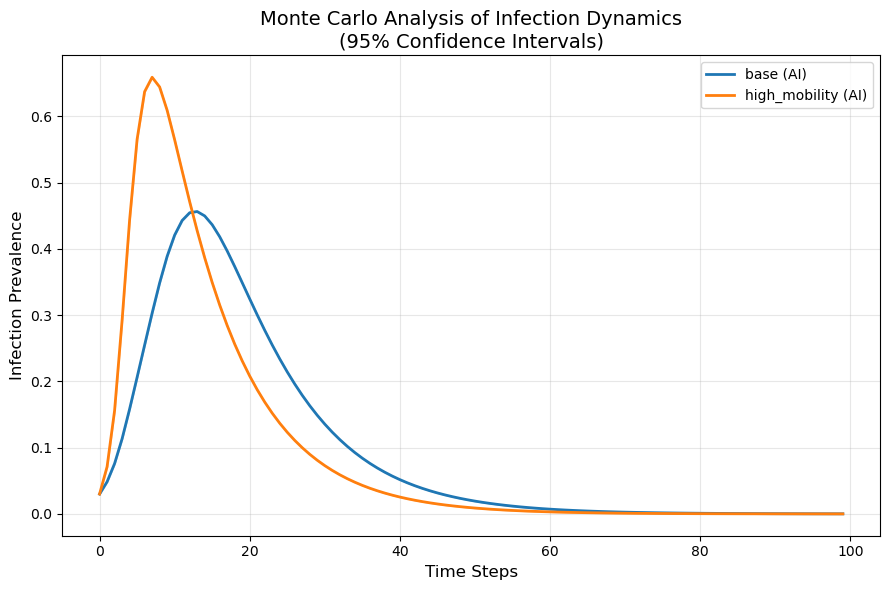

In [40]:
# 新增蒙特卡洛分析类
import datetime

from tqdm import tqdm


class MonteCarloAnalyzer:
    def __init__(self, params, num_simulations):
        self.params = params
        self.num_simulations = num_simulations
        self.results = {
            'US': np.zeros((num_simulations, params['Time'])),
            'AS': np.zeros((num_simulations, params['Time'])),
            'AI': np.zeros((num_simulations, params['Time'])),
            'UR': np.zeros((num_simulations, params['Time'])),
            'AR': np.zeros((num_simulations, params['Time']))
        }

    def run_experiments(self):
        for sim in tqdm(range(self.num_simulations), desc="Running Monte Carlo simulations"):
            # 每次实验重新初始化随机网络
            state_history, pop_history = main_simulation(
                self.params['Time'],
                self.params['N'],
                self.params['M'],
                self.params
            )
            
            # 记录全局状态比例
            for t in range(self.params['Time']):
                total_state = np.sum(state_history[t] * pop_history[t][:, None], axis=0)
                total_pop = np.sum(pop_history[t])
                self.results['US'][sim, t] = total_state[0] / total_pop
                self.results['AS'][sim, t] = total_state[1] / total_pop
                self.results['AI'][sim, t] = total_state[2] / total_pop
                self.results['UR'][sim, t] = total_state[3] / total_pop
                self.results['AR'][sim, t] = total_state[4] / total_pop

    def analyze_results(self):
        analysis = {}
        for state in ['US', 'AS', 'AI', 'UR', 'AR']:
            analysis[state] = {
                'mean': np.mean(self.results[state], axis=0),
                'std': np.std(self.results[state], axis=0),
                'ci': 1.96 * np.std(self.results[state], axis=0) / np.sqrt(self.num_simulations)
            }
        return analysis

# 修改主程序流程
if __name__ == "__main__":
    # =====================
    # 参数配置
    # =====================
    # 参数设置
    base_params = {
        'Time': 100,
        'N': 20,
        'M': 5,
        'beta1': 0.2,
        'mu1': 0.15,
        'mu2': 0.1,
        'beta_U': 0.003,
        'beta_A': 0.0015,
        'g': 0.5,
        'gamma': 0.8,
        'epsilon0': 0.3,
        'alpha': 0.2,
        'theta': 1,
        'kappa': 1
    }

    # =====================
    # 蒙特卡洛实验配置
    # =====================
    experiment_config = {
        'base': {
            'params': base_params,
            'num_simulations': 500,
            'color': '#1f77b4'
        },
        # 可以添加不同参数组合的实验
        'high_mobility': {
            'params': {**base_params, 'g': 0.8},
            'num_simulations': 500,
            'color': '#ff7f0e'
        }
    }

    # =====================
    # 运行实验并可视化
    # =====================
    plt.figure(figsize=(9, 6))
    
    for exp_name, config in experiment_config.items():
        analyzer = MonteCarloAnalyzer(config['params'], config['num_simulations'])
        analyzer.run_experiments()
        results = analyzer.analyze_results()
        
        # 绘制主要感染状态（AI）
        mean = results['AI']['mean']
        ci = results['AI']['ci']
        
        plt.plot(mean, label=f'{exp_name} (AI)', color=config['color'], lw=2)
        plt.fill_between(range(len(mean)), 
                        mean - ci, 
                        mean + ci, 
                        color=config['color'], alpha=0.2)

    # 图表美化
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Infection Prevalence', fontsize=12)
    plt.title('Monte Carlo Analysis of Infection Dynamics\n(95% Confidence Intervals)', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # 保存结果
    # timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    # plt.savefig(f'monte_carlo_results_{timestamp}.png', dpi=300)
    plt.show()

    # 可选：保存原始数据
    # if SAVE_RAW_DATA:
    #     with open(f'mc_raw_data_{timestamp}.pkl', 'wb') as f:
    #         pickle.dump(analyzer.results, f)

Running Monte Carlo simulations: 100%|██████████| 10/10 [00:01<00:00,  9.97it/s]


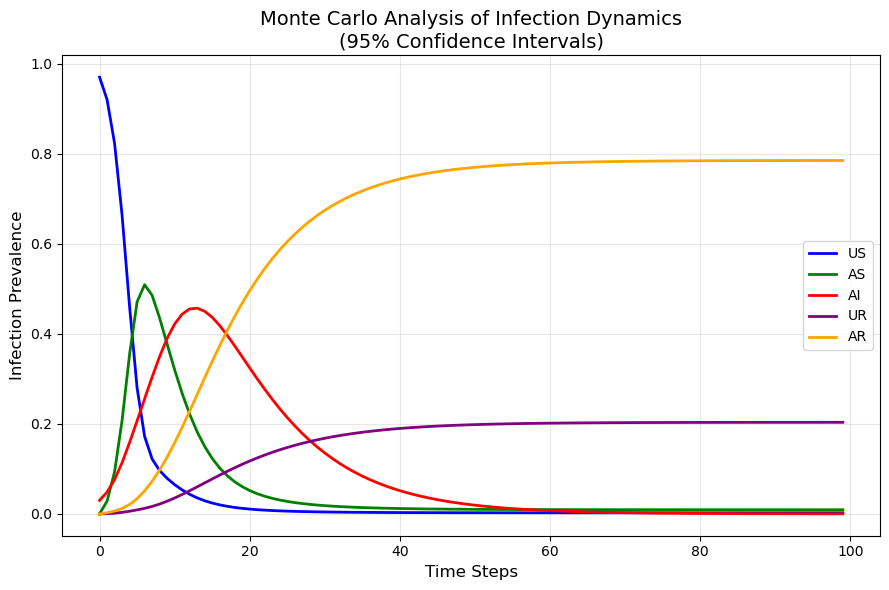

In [43]:
# 新增蒙特卡洛分析类
import datetime

from tqdm import tqdm


class MonteCarloAnalyzer:
    def __init__(self, params, num_simulations):
        self.params = params
        self.num_simulations = num_simulations
        self.results = {
            'US': np.zeros((num_simulations, params['Time'])),
            'AS': np.zeros((num_simulations, params['Time'])),
            'AI': np.zeros((num_simulations, params['Time'])),
            'UR': np.zeros((num_simulations, params['Time'])),
            'AR': np.zeros((num_simulations, params['Time']))
        }

    def run_experiments(self):
        for sim in tqdm(range(self.num_simulations), desc="Running Monte Carlo simulations"):
            # 每次实验重新初始化随机网络
            state_history, pop_history = main_simulation(
                self.params['Time'],
                self.params['N'],
                self.params['M'],
                self.params
            )
            
            # 记录全局状态比例
            for t in range(self.params['Time']):
                total_state = np.sum(state_history[t] * pop_history[t][:, None], axis=0)
                total_pop = np.sum(pop_history[t])
                self.results['US'][sim, t] = total_state[0] / total_pop
                self.results['AS'][sim, t] = total_state[1] / total_pop
                self.results['AI'][sim, t] = total_state[2] / total_pop
                self.results['UR'][sim, t] = total_state[3] / total_pop
                self.results['AR'][sim, t] = total_state[4] / total_pop

    def analyze_results(self):
        analysis = {}
        for state in ['US', 'AS', 'AI', 'UR', 'AR']:
            analysis[state] = {
                'mean': np.mean(self.results[state], axis=0),
                'std': np.std(self.results[state], axis=0),
                'ci': 1.96 * np.std(self.results[state], axis=0) / np.sqrt(self.num_simulations)
            }
        return analysis

# 修改主程序流程
if __name__ == "__main__":
    # =====================
    # 参数配置
    # =====================
    # 参数设置
    num_simulations = 10
    base_params = {
        'Time': 100,
        'N': 20,
        'M': 5,
        'beta1': 0.2,
        'mu1': 0.15,
        'mu2': 0.1,
        'beta_U': 0.003,
        'beta_A': 0.0015,
        'g': 0.5,
        'gamma': 0.8,
        'epsilon0': 0.3,
        'alpha': 0.2,
        'theta': 1,
        'kappa': 1
    }


    # =====================
    # 运行实验并可视化
    # =====================

    
    analyzer = MonteCarloAnalyzer(base_params, num_simulations)
    analyzer.run_experiments()
    results = analyzer.analyze_results()

    state_colors = {
        'US': 'blue',
        'AS': 'green',
        'AI': 'red',
        'UR': 'purple',
        'AR': 'orange'
    }


    plt.figure(figsize=(9, 6))
    
    state_labels = ['US', 'AS', 'AI', 'UR', 'AR']

    for i , (label, color) in enumerate(zip(state_labels, state_colors.values())):
        plt.plot(results[label]['mean'], label=label, color=color, lw=2)
    
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Infection Prevalence', fontsize=12)
    plt.title('Monte Carlo Analysis of Infection Dynamics\n(95% Confidence Intervals)', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # 显示图表
    plt.show()
    

In [44]:
import pandas as pd

print(results['US']['mean'])

results_df = pd.DataFrame(
    results['US']['mean'],
    columns=['US']
)

print(results_df)

[0.97       0.92009252 0.82284019 0.6630578  0.45986496 0.27958507
 0.17203164 0.1218356  0.09625131 0.07893527 0.06497027 0.05324448
 0.04349764 0.03554517 0.0291544  0.02406755 0.0200367  0.01684417
 0.0143094  0.01228778 0.01066598 0.00935625 0.008291   0.00741834
 0.0066983  0.00610003 0.00559961 0.00517835 0.00482143 0.00451751
 0.00425756 0.00403403 0.00384095 0.00367347 0.00352764 0.00340022
 0.00328852 0.00319032 0.00310375 0.00302725 0.00295951 0.00289938
 0.00284593 0.00279833 0.00275587 0.00271794 0.00268403 0.00265366
 0.00262645 0.00260203 0.00258011 0.00256042 0.0025427  0.00252677
 0.00251242 0.00249949 0.00248785 0.00247735 0.00246787 0.00245933
 0.00245161 0.00244465 0.00243836 0.00243268 0.00242755 0.00242291
 0.00241872 0.00241493 0.00241151 0.00240841 0.00240561 0.00240308
 0.00240079 0.00239871 0.00239684 0.00239514 0.00239361 0.00239222
 0.00239096 0.00238983 0.0023888  0.00238787 0.00238702 0.00238626
 0.00238557 0.00238494 0.00238438 0.00238387 0.0023834  0.0023